In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('./data.csv', header=None)

data = data.drop(columns=0)
data.describe()

,2,3,4,5,6,7,8,9,10,11,...,22,23,24,25,26,27,28,29,30,31
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [2]:
X = data.iloc[:,1:].values
y = pd.get_dummies(data[1], dtype=int).values

print(X.shape)
print(y.shape)

(569, 30)
(569, 2)


In [3]:
from microtorch.data import random_split, StandardScaler, DataLoader

(X_train, y_train), (X_test, y_test) = random_split(X, y, ratios=[0.8, 0.2], seed=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


print((y[:, 0] == 1).mean())
print((y_train[:, 0] == 1).mean())
print((y_test[:, 0] == 1).mean())

(456, 30)
(113, 30)
(456, 2)
(113, 2)
0.6274165202108963
0.6271929824561403
0.6283185840707964


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(np.round(X_train.mean(axis=0), 3))
print(X_train.std(axis=0))

[-0. -0. -0. -0.  0. -0. -0.  0. -0.  0. -0. -0. -0. -0. -0. -0.  0. -0.
  0.  0. -0.  0. -0.  0.  0. -0. -0.  0. -0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [5]:
BATCH_SIZE=16

train_loader = DataLoader(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

test_loader = DataLoader(
    X_test, y_test,
    batch_size=BATCH_SIZE
)

print(len(train_loader))
print(len(test_loader))

29
8


In [6]:
LR = 0.03
epochs = 50


from microtorch import models
from microtorch.optimizers import SGD
from microtorch.functions import cross_entropy_loss
from microtorch import nn
from tqdm import tqdm

np.random.seed(1337)

n_features = X.shape[1]

model = models.MLP(
    in_size=n_features,
    out_size=2,
    hidden_layers=[5],
    activations=['relu']
)

softmax = nn.Softmax()

optimizer = SGD(model, lr=0.01)

loss_fn = cross_entropy_loss

def acc_fn(y_pred, y_true):
    y_pred = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_true, axis=1)
    return (y_pred == y_true).mean()


loss_hist = []
train_acc_h = []
test_acc_h = []

train_acc = acc_fn(model(X_train), y_train)
test_acc = acc_fn(model(X_test), y_test)

print(f"Before Training: Train Accuracy {train_acc:.2f} | Test Accuracy {test_acc:.2f}")

for e in range(epochs):
    train_loss = 0
    for X, y in tqdm(train_loader, f"Epoch #{e}"):
        optimizer.zero_grad()
        
        y_pred = model(X)
        
        y_pred = softmax(y_pred)
    
        l = loss_fn(y_pred, y)

        train_loss += l.val

        l.backprop()
        
        optimizer.step()

    train_loss /= len(train_loader)

    # accuracy
    train_acc = acc_fn(model(X_train), y_train)
    test_acc = acc_fn(model(X_test), y_test)

    loss_hist.append(train_loss)
    train_acc_h.append(train_acc)
    test_acc_h.append(test_acc)

    print(f"Epoch #{e}: Loss {train_loss} | Train Accuracy {train_acc:.2f} | Test Accuracy {test_acc:.2f}")

Before Training: Train Accuracy 0.72 | Test Accuracy 0.71


Epoch #0: 100%|███████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 22.24it/s]


Epoch #0: Loss 0.505309122903572 | Train Accuracy 0.83 | Test Accuracy 0.82


Epoch #1: 100%|███████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 24.48it/s]


Epoch #1: Loss 0.42543556373449587 | Train Accuracy 0.86 | Test Accuracy 0.88


...

Epoch #47: Loss 0.08791887781728278 | Train Accuracy 0.97 | Test Accuracy 0.98


Epoch #48: 100%|██████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 27.33it/s]


Epoch #48: Loss 0.08728310643286825 | Train Accuracy 0.97 | Test Accuracy 0.98


Epoch #49: 100%|██████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 25.28it/s]


Epoch #49: Loss 0.0892824377145039 | Train Accuracy 0.97 | Test Accuracy 0.98


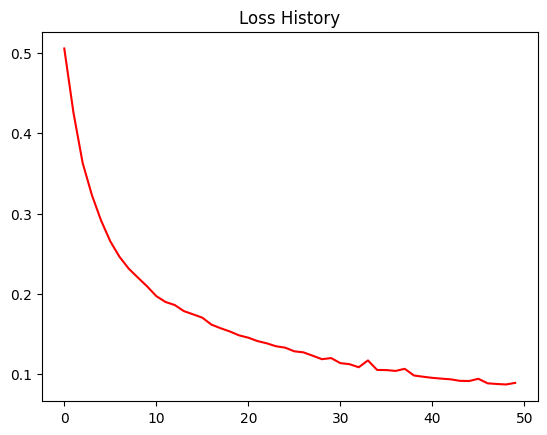

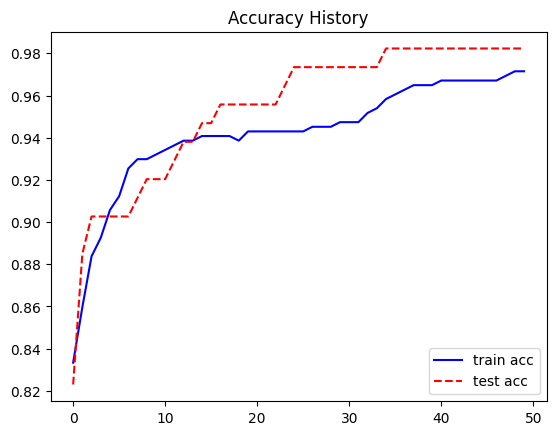

In [9]:
import matplotlib.pyplot as plt

eps = np.arange(epochs)

plt.title('Loss History')
plt.plot(eps, loss_hist, 'r-')
plt.show()

plt.title('Accuracy History')
plt.plot(eps, train_acc_h, 'b-', label='train acc')
plt.plot(eps, test_acc_h, 'r--', label='test acc')
plt.legend(loc="lower right")
plt.show()